# IN5437 — Assignment 1
## Question 7: Image Zooming (Nearest-Neighbor + Bilinear Interpolation)

**Name:** Benjamine  
**Index:** 258762A

- (a) Zoom function using **nearest-neighbor** interpolation.
- (b) Zoom function using **bilinear** interpolation.
- Test: zoom small image up, compute normalized SSD vs original large image.

In [12]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os

### Nearest-neighbor zoom function

For each output pixel (i, j), find the source coordinate (i/s, j/s) and round to the nearest integer.

In [13]:
def zoom_nearest(image, s):
    # Zoom an image by factor s using nearest-neighbor interpolation.
    in_h, in_w = image.shape[:2]
    out_h = int(round(in_h * s))
    out_w = int(round(in_w * s))

    # Output array (same number of channels as input)
    if image.ndim == 2:
        out = np.zeros((out_h, out_w), dtype=image.dtype)
    else:
        out = np.zeros((out_h, out_w, image.shape[2]), dtype=image.dtype)

    for i in range(out_h):
        for j in range(out_w):
            # Source coordinate for this output pixel
            src_y = int(round(i / s))
            src_x = int(round(j / s))
            # Clip to input bounds (safety for edge pixels)
            src_y = min(src_y, in_h - 1)
            src_x = min(src_x, in_w - 1)
            out[i, j] = image[src_y, src_x]

    return out

### Bilinear zoom function

For each output pixel, find the fractional source coordinate and blend the 4 surrounding input pixels.

In [14]:
def zoom_bilinear(image, s):
    # Zoom an image by factor s using bilinear interpolation.
    in_h, in_w = image.shape[:2]
    out_h = int(round(in_h * s))
    out_w = int(round(in_w * s))

    # Work in float for the blending, convert back at the end
    image_f = image.astype(np.float32)
    if image.ndim == 2:
        out = np.zeros((out_h, out_w), dtype=np.float32)
    else:
        out = np.zeros((out_h, out_w, image.shape[2]), dtype=np.float32)

    for i in range(out_h):
        for j in range(out_w):
            # Fractional source coordinates
            src_y = i / s
            src_x = j / s

            # Integer corners (top-left)
            y0 = int(np.floor(src_y))
            x0 = int(np.floor(src_x))
            y1 = min(y0 + 1, in_h - 1)
            x1 = min(x0 + 1, in_w - 1)
            y0 = min(y0, in_h - 1)
            x0 = min(x0, in_w - 1)

            # Fractional distances
            a = src_y - y0
            b = src_x - x0

            # Blend the 4 surrounding pixels
            A = image_f[y0, x0]
            B = image_f[y0, x1]
            C = image_f[y1, x0]
            D = image_f[y1, x1]

            out[i, j] = (1 - a) * (1 - b) * A + (1 - a) * b * B + a * (1 - b) * C + a * b * D

    return np.clip(out, 0, 255).astype(image.dtype)

### Test: zoom a small image and compare with the large original

Compute the **normalized SSD** — sum of squared differences divided by the total number of pixels. Lower = closer match.

In [15]:
large_path = '../images/q7/im01.png'
small_path = '../images/q7/im01small.png'

large = cv.imread(large_path, cv.IMREAD_GRAYSCALE)
small = cv.imread(small_path, cv.IMREAD_GRAYSCALE)
assert large is not None and small is not None, "Check the paths."

print(f'Large shape: {large.shape}')
print(f'Small shape: {small.shape}')

# Zoom factor needed to match
s = large.shape[0] / small.shape[0]
print(f'Zoom factor: {s:.3f}')

Large shape: (1080, 1920)
Small shape: (270, 480)
Zoom factor: 4.000


In [16]:
z_nn = zoom_nearest(small, s)
z_bl = zoom_bilinear(small, s)

print(f'Nearest shape: {z_nn.shape}')
print(f'Bilinear shape: {z_bl.shape}')
print(f'Target (large) shape: {large.shape}')

Nearest shape: (1080, 1920)
Bilinear shape: (1080, 1920)
Target (large) shape: (1080, 1920)


In [17]:
# Due to integer rounding, zoomed shape may differ from original by 1 pixel.
# Crop to the common shape so SSD can be computed.
h = min(large.shape[0], z_nn.shape[0], z_bl.shape[0])
w = min(large.shape[1], z_nn.shape[1], z_bl.shape[1])
large_c = large[:h, :w]
z_nn_c  = z_nn[:h, :w]
z_bl_c  = z_bl[:h, :w]

In [18]:
def normalized_ssd(a, b):
    # Normalized sum of squared differences between two images.
    a = a.astype(np.float64)
    b = b.astype(np.float64)
    return np.sum((a - b) ** 2) / a.size

ssd_nn = normalized_ssd(large_c, z_nn_c)
ssd_bl = normalized_ssd(large_c, z_bl_c)

print(f'Normalized SSD — nearest-neighbor: {ssd_nn:.4f}')
print(f'Normalized SSD — bilinear        : {ssd_bl:.4f}')

Normalized SSD — nearest-neighbor: 256.8222
Normalized SSD — bilinear        : 201.4494


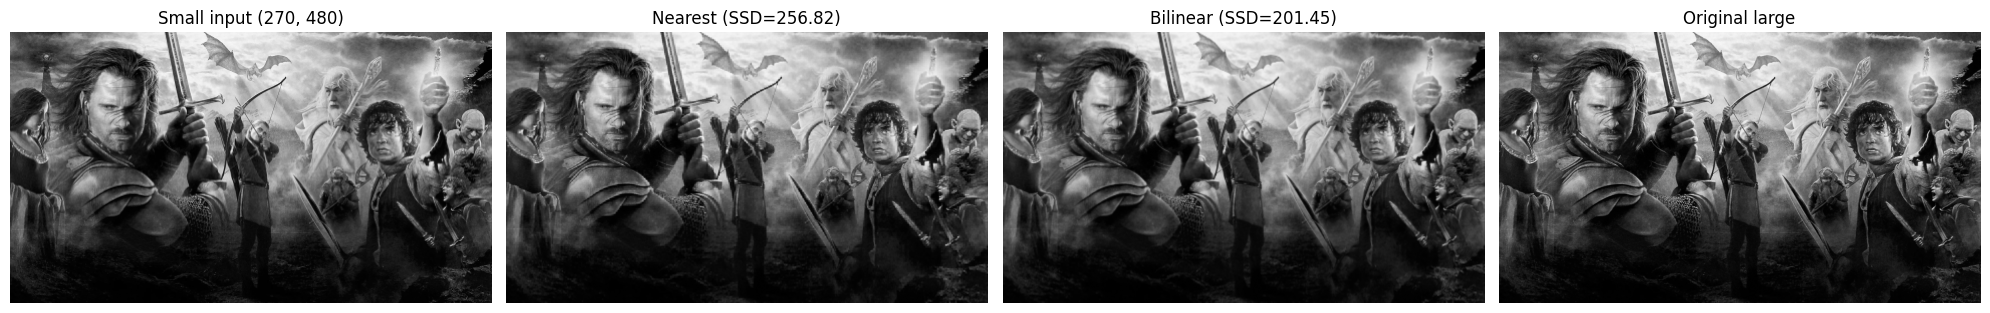

In [19]:
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(small,   cmap='gray', vmin=0, vmax=255); ax[0].set_title(f'Small input {small.shape}'); ax[0].axis('off')
ax[1].imshow(z_nn_c,  cmap='gray', vmin=0, vmax=255); ax[1].set_title(f'Nearest (SSD={ssd_nn:.2f})'); ax[1].axis('off')
ax[2].imshow(z_bl_c,  cmap='gray', vmin=0, vmax=255); ax[2].set_title(f'Bilinear (SSD={ssd_bl:.2f})'); ax[2].axis('off')
ax[3].imshow(large_c, cmap='gray', vmin=0, vmax=255); ax[3].set_title('Original large'); ax[3].axis('off')
plt.tight_layout()
plt.show()

### Test on all available image pairs

If you have multiple image pairs (a1/a1_small, a2/a2_small, ...), loop over them and produce an SSD table.

In [20]:
pairs = [
    ('../images/q7/im01.png', '../images/q7/im01small.png'),
    ('../images/q7/im02.png', '../images/q7/im02small.png'),
    ('../images/q7/im03.png', '../images/q7/im03small.png'),
]

print(f'{"File":<20} {"Factor":>8} {"SSD (NN)":>12} {"SSD (Bilinear)":>16}')
print('-' * 60)

for large_path, small_path in pairs:
    if not (os.path.exists(large_path) and os.path.exists(small_path)):
        print(f'{os.path.basename(large_path):<20}  (file missing — skipped)')
        continue

    large = cv.imread(large_path, cv.IMREAD_GRAYSCALE)
    small = cv.imread(small_path, cv.IMREAD_GRAYSCALE)

    s = large.shape[0] / small.shape[0]
    z_nn = zoom_nearest(small, s)
    z_bl = zoom_bilinear(small, s)

    h = min(large.shape[0], z_nn.shape[0], z_bl.shape[0])
    w = min(large.shape[1], z_nn.shape[1], z_bl.shape[1])

    ssd_nn = normalized_ssd(large[:h, :w], z_nn[:h, :w])
    ssd_bl = normalized_ssd(large[:h, :w], z_bl[:h, :w])

    print(f'{os.path.basename(large_path):<20} {s:>8.3f} {ssd_nn:>12.2f} {ssd_bl:>16.2f}')

File                   Factor     SSD (NN)   SSD (Bilinear)
------------------------------------------------------------
im01.png                4.000       256.82           201.45
im02.png                4.000        65.42            49.56
im03.png                3.997       173.68           135.54
